# timesfm experiment v2 — zero-shot seasonal residual and honest calibration

v1 obtained `1672.25` wmae without training. v2 still performs **no fine-tuning** and adds two ideas: timesfm forecasting of the deviation from the 52-week seasonal baseline, and a non-negative three-way blend selected on a historical calibration window that is separate from the final 39-week validation period.

In [ ]:
%pip install -q -U "transformers>=5.3.0" accelerate wandb

In [1]:
import hashlib, json, platform, time, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch, transformers, wandb
from transformers import TimesFm2_5ModelForPrediction
warnings.filterwarnings('ignore')
torch.set_float32_matmul_precision('high')
print({'python': platform.python_version(), 'torch': torch.__version__, 'transformers': transformers.__version__, 'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})

{'python': '3.12.13', 'torch': '2.11.0+cu128', 'transformers': '5.12.1', 'gpu': 'Tesla T4'}


In [2]:
CONFIG = {
    'data_dir': '/content/drive/MyDrive/walmart_competition_data',
    'output_dir': '/content/artifacts/timesfm_zero_shot_v2',
    'model_id': 'google/timesfm-2.5-200m-transformers',
    'validation_weeks': 39, 'calibration_weeks': 20, 'seasonal_period': 52,
    'batch_size': 64, 'weight_step': 0.05, 'holiday_weight': 5.0,
    'clip_min': 0.0, 'clip_max': 300000.0, 'seed': 42,
    'wandb_entity': 'kende23-n-a',
    'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
    'wandb_run_name': 'timesfm_v2_zero_shot_residual_calibrated_blend',
}
DATA_DIR, OUTPUT_DIR = Path(CONFIG['data_dir']), Path(CONFIG['output_dir'])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(CONFIG['seed'])
print(CONFIG)

{'data_dir': '/content/drive/MyDrive/walmart_competition_data', 'output_dir': '/content/artifacts/timesfm_zero_shot_v2', 'model_id': 'google/timesfm-2.5-200m-transformers', 'validation_weeks': 39, 'calibration_weeks': 20, 'seasonal_period': 52, 'batch_size': 64, 'weight_step': 0.05, 'holiday_weight': 5.0, 'clip_min': 0.0, 'clip_max': 300000.0, 'seed': 42, 'wandb_entity': 'kende23-n-a', 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting', 'wandb_run_name': 'timesfm_v2_zero_shot_residual_calibrated_blend'}


In [5]:
from google.colab import drive
import os

# mount google drive
drive.mount('/content/drive')

# verify the directory contents
if DATA_DIR.exists():
    print(f"Files in {DATA_DIR}:")
    print(os.listdir(DATA_DIR))
else:
    print(f"Directory NOT found: {DATA_DIR}")

Mounted at /content/drive
Files in /content/drive/MyDrive/walmart_competition_data:
['train.csv.zip', 'stores.csv', 'features.csv.zip', 'sampleSubmission.csv.zip', 'test.csv.zip', 'features.csv', 'test.csv', 'train.csv']


In [3]:
try:
    from google.colab import userdata
    wandb_key = userdata.get('WANDB_API_KEY')
except Exception:
    wandb_key = None
wandb.login(key=wandb_key) if wandb_key else wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## data and three-way chronological split

the final 39 weeks remain untouched for evaluation. the preceding 20 weeks select blend weights, and all earlier weeks form the calibration context. no final-validation target participates in weight selection.

In [6]:
def locate_csv(root, name):
    for path in [root / name, root / f'{name}.zip']:
        if path.exists(): return path
    raise FileNotFoundError(f'Missing {name} or {name}.zip in {root}')

def wmae(actual, predicted, holiday, holiday_weight=5.0):
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)
    weights = np.where(np.asarray(holiday, bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(actual - predicted)) / np.sum(weights))

# re-attempting load now that drive is mounted
train = pd.read_csv(locate_csv(DATA_DIR, 'train.csv'), parse_dates=['Date'])
train['Weekly_Sales'] = pd.to_numeric(train['Weekly_Sales'], errors='coerce').fillna(0.0).astype('float32')
train['IsHoliday'] = train['IsHoliday'].astype(bool)
train = train.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
all_dates = pd.DatetimeIndex(sorted(train.Date.unique()))
final_start = len(all_dates) - CONFIG['validation_weeks']
calibration_start = final_start - CONFIG['calibration_weeks']
calibration_dates = all_dates[calibration_start:final_start]
validation_dates = all_dates[final_start:]
evaluation_keys = sorted(map(tuple, train[train.Date.isin(validation_dates)][['Store','Dept']].drop_duplicates().to_numpy()))
lookup = train.set_index(['Store','Dept','Date'])['Weekly_Sales']
sales = np.zeros((len(evaluation_keys), len(all_dates)), dtype=np.float32)
for i, (store, dept) in enumerate(evaluation_keys):
    idx = pd.MultiIndex.from_product([[store], [dept], all_dates], names=['Store','Dept','Date'])
    sales[i] = lookup.reindex(idx).fillna(0.0).to_numpy(np.float32)
key_to_index = {key:i for i,key in enumerate(evaluation_keys)}
print({'all_rows':len(train),'all_series':train.groupby(['Store','Dept']).ngroups,'evaluated_series':len(evaluation_keys),'calibration':f'{calibration_dates.min().date()} -> {calibration_dates.max().date()}','validation':f'{validation_dates.min().date()} -> {validation_dates.max().date()}','raw_calibration_context_weeks':calibration_start,'raw_final_context_weeks':final_start})

{'all_rows': 421570, 'all_series': 3331, 'evaluated_series': 3204, 'calibration': '2011-09-16 -> 2012-01-27', 'validation': '2012-02-03 -> 2012-10-26', 'raw_calibration_context_weeks': 84, 'raw_final_context_weeks': 104}


In [7]:
# the residual at week t is sales(t) - sales(t-52).
period = CONFIG['seasonal_period']
residual = sales[:, period:] - sales[:, :-period]
raw_context_cal = sales[:, :calibration_start]
raw_context_final = sales[:, :final_start]
residual_context_cal = residual[:, :calibration_start-period]
residual_context_final = residual[:, :final_start-period]
seasonal_cal = sales[:, calibration_start-period:final_start-period]
seasonal_final = sales[:, final_start-period:len(all_dates)-period]
assert residual_context_cal.shape[1] >= 32
assert seasonal_cal.shape[1] == CONFIG['calibration_weeks']
assert seasonal_final.shape[1] == CONFIG['validation_weeks']
print({'residual_calibration_context':residual_context_cal.shape[1], 'residual_final_context':residual_context_final.shape[1]})

{'residual_calibration_context': 32, 'residual_final_context': 52}


## load timesfm once and forecast raw sales plus seasonal residuals

In [8]:
if not torch.cuda.is_available(): print('WARNING: select a T4 GPU in Colab.')
load_started = time.time()
model = TimesFm2_5ModelForPrediction.from_pretrained(CONFIG['model_id'], torch_dtype=torch.float32, device_map='auto' if torch.cuda.is_available() else None)
model.eval()
load_seconds = time.time() - load_started
print({'device':str(model.device),'parameters':sum(p.numel() for p in model.parameters()),'load_seconds':load_seconds})

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

{'device': 'cuda:0', 'parameters': 231289280, 'load_seconds': 14.08599328994751}


In [9]:
def forecast_matrix(name, contexts, horizon):
    started = time.time(); predictions = []
    print(f'{name}: {len(contexts)} series, context={contexts.shape[1]}, horizon={horizon}')
    with torch.inference_mode():
        for start in range(0, len(contexts), CONFIG['batch_size']):
            batch = torch.as_tensor(contexts[start:start+CONFIG['batch_size']], dtype=torch.float32, device=model.device)
            output = model(past_values=batch, return_dict=True).mean_predictions[:, :horizon]
            predictions.append(output.detach().float().cpu().numpy())
            if start == 0 or (start // CONFIG['batch_size'] + 1) % 10 == 0:
                print(f'  {min(start+CONFIG["batch_size"],len(contexts))}/{len(contexts)} | {(time.time()-started)/60:.2f} min')
    result = np.concatenate(predictions).astype(np.float32)
    result = np.nan_to_num(result, nan=0.0, posinf=CONFIG['clip_max'], neginf=-CONFIG['clip_max'])
    print(f'{name} finished in {(time.time()-started)/60:.2f} min')
    return result

inference_started = time.time()
raw_cal = forecast_matrix('raw calibration', raw_context_cal, CONFIG['calibration_weeks'])
resid_cal = forecast_matrix('residual calibration', residual_context_cal, CONFIG['calibration_weeks'])
raw_final = forecast_matrix('raw final', raw_context_final, CONFIG['validation_weeks'])
resid_final = forecast_matrix('residual final', residual_context_final, CONFIG['validation_weeks'])
inference_minutes = (time.time()-inference_started)/60
raw_cal = np.clip(raw_cal, CONFIG['clip_min'], CONFIG['clip_max'])
raw_final = np.clip(raw_final, CONFIG['clip_min'], CONFIG['clip_max'])
residual_reconstructed_cal = np.clip(seasonal_cal + resid_cal, CONFIG['clip_min'], CONFIG['clip_max'])
residual_reconstructed_final = np.clip(seasonal_final + resid_final, CONFIG['clip_min'], CONFIG['clip_max'])
peak_gpu_gb = torch.cuda.max_memory_allocated()/1024**3 if torch.cuda.is_available() else 0.0
print({'total_inference_minutes':inference_minutes,'peak_gpu_gb':peak_gpu_gb})

raw calibration: 3204 series, context=84, horizon=20
  64/3204 | 0.19 min
  640/3204 | 1.87 min
  1280/3204 | 3.80 min
  1920/3204 | 5.74 min
  2560/3204 | 7.66 min
  3200/3204 | 9.59 min
raw calibration finished in 9.61 min
residual calibration: 3204 series, context=32, horizon=20
  64/3204 | 0.19 min
  640/3204 | 1.92 min
  1280/3204 | 3.85 min
  1920/3204 | 5.78 min
  2560/3204 | 7.71 min
  3200/3204 | 9.63 min
residual calibration finished in 9.65 min
raw final: 3204 series, context=104, horizon=39
  64/3204 | 0.19 min
  640/3204 | 1.92 min
  1280/3204 | 3.85 min
  1920/3204 | 5.78 min
  2560/3204 | 7.70 min
  3200/3204 | 9.62 min
raw final finished in 9.65 min
residual final: 3204 series, context=52, horizon=39
  64/3204 | 0.19 min
  640/3204 | 1.92 min
  1280/3204 | 3.85 min
  1920/3204 | 5.77 min
  2560/3204 | 7.70 min
  3200/3204 | 9.62 min
residual final finished in 9.65 min
{'total_inference_minutes': 38.55799411535263, 'peak_gpu_gb': 6.668726444244385}


## select blend weights on calibration only

the three candidates are seasonalnaive52, raw timesfm, and reconstructed timesfm residual. we search non-negative weights that sum to one.

In [10]:
def make_frame(dates, seasonal, raw_pred, residual_pred):
    source = train[train.Date.isin(dates) & train.set_index(['Store','Dept']).index.isin(evaluation_keys)].copy()
    horizon_map = {d:i for i,d in enumerate(dates)}
    rows=[]
    for r in source.itertuples(index=False):
        i, h = key_to_index[(r.Store,r.Dept)], horizon_map[r.Date]
        rows.append({'Store':int(r.Store),'Dept':int(r.Dept),'Date':r.Date,'IsHoliday':bool(r.IsHoliday),'Weekly_Sales':float(r.Weekly_Sales),'Horizon':h+1,'SeasonalNaive52':float(seasonal[i,h]),'TimesFM_Raw':float(raw_pred[i,h]),'TimesFM_Residual':float(residual_pred[i,h])})
    return pd.DataFrame(rows).sort_values(['Date','Store','Dept']).reset_index(drop=True)

calibration_df = make_frame(calibration_dates, seasonal_cal, raw_cal, residual_reconstructed_cal)
validation_df = make_frame(validation_dates, seasonal_final, raw_final, residual_reconstructed_final)
grid=[]; steps=int(round(1/CONFIG['weight_step']))
for a in range(steps+1):
    for b in range(steps-a+1):
        w_naive=a/steps; w_raw=b/steps; w_residual=1-w_naive-w_raw
        pred=w_naive*calibration_df.SeasonalNaive52+w_raw*calibration_df.TimesFM_Raw+w_residual*calibration_df.TimesFM_Residual
        grid.append({'w_naive':w_naive,'w_raw':w_raw,'w_residual':w_residual,'calibration_wmae':wmae(calibration_df.Weekly_Sales,pred,calibration_df.IsHoliday,CONFIG['holiday_weight'])})
weight_search=pd.DataFrame(grid).sort_values('calibration_wmae').reset_index(drop=True)
best=weight_search.iloc[0].to_dict()
for frame in [calibration_df, validation_df]:
    frame['TimesFM_CalibratedBlend']=np.clip(best['w_naive']*frame.SeasonalNaive52+best['w_raw']*frame.TimesFM_Raw+best['w_residual']*frame.TimesFM_Residual,CONFIG['clip_min'],CONFIG['clip_max'])
print('Best calibration weights:',best)
display(weight_search.head(10))

Best calibration weights: {'w_naive': 0.45, 'w_raw': 0.1, 'w_residual': 0.45000000000000007, 'calibration_wmae': 1908.580984234162}


,w_naive,w_raw,w_residual,calibration_wmae
0,0.45,0.10,0.45,1908.580984
1,0.50,0.10,0.40,1908.997462
2,0.40,0.10,0.50,1910.840856
3,0.55,0.10,0.35,1912.229192
4,0.35,0.10,0.55,1915.616742
5,0.45,0.15,0.40,1916.984781
6,0.40,0.15,0.45,1918.087715
7,0.50,0.15,0.35,1918.585950
8,0.60,0.10,0.30,1918.991548
9,0.50,0.05,0.45,1921.642445


In [11]:
candidate_columns=['SeasonalNaive52','TimesFM_Raw','TimesFM_Residual','TimesFM_CalibratedBlend']
scores=[]
for name in candidate_columns:
    scores.append({'candidate':name,'calibration_wmae':wmae(calibration_df.Weekly_Sales,calibration_df[name],calibration_df.IsHoliday,CONFIG['holiday_weight']),'validation_wmae':wmae(validation_df.Weekly_Sales,validation_df[name],validation_df.IsHoliday,CONFIG['holiday_weight']),'validation_mae':float(np.mean(np.abs(validation_df.Weekly_Sales-validation_df[name])))})
score_table=pd.DataFrame(scores).sort_values('validation_wmae').reset_index(drop=True)
display(score_table)
final_wmae=float(score_table.loc[score_table.candidate=='TimesFM_CalibratedBlend','validation_wmae'].iloc[0])
v1_wmae=float(score_table.loc[score_table.candidate=='TimesFM_Raw','validation_wmae'].iloc[0])
metrics={
 'validation/wmae':final_wmae,'validation/raw_timesfm_wmae':v1_wmae,
 'validation/residual_timesfm_wmae':float(score_table.loc[score_table.candidate=='TimesFM_Residual','validation_wmae'].iloc[0]),
 'validation/seasonal_naive_wmae':float(score_table.loc[score_table.candidate=='SeasonalNaive52','validation_wmae'].iloc[0]),
 'validation/improvement_vs_raw_timesfm_pct':100*(v1_wmae-final_wmae)/v1_wmae,
 'calibration/best_w_naive':best['w_naive'],'calibration/best_w_raw':best['w_raw'],'calibration/best_w_residual':best['w_residual'],'calibration/best_wmae':best['calibration_wmae'],
 'runtime/model_load_seconds':load_seconds,'runtime/inference_minutes':inference_minutes,'runtime/peak_gpu_gb':peak_gpu_gb,'coverage/series':len(evaluation_keys),
}
prediction_hash=hashlib.sha256(validation_df.TimesFM_CalibratedBlend.to_numpy(np.float64).tobytes()).hexdigest()
print(metrics); print({'prediction_sha256':prediction_hash})

,candidate,calibration_wmae,validation_wmae,validation_mae
0,TimesFM_CalibratedBlend,1935.866733,1620.543031,1621.643962
1,TimesFM_Raw,3601.472594,1672.252523,1611.639231
2,TimesFM_Residual,2072.957605,1720.170896,1736.145253
3,SeasonalNaive52,2106.711314,1799.045095,1796.054886


{'validation/wmae': 1620.5430312667477, 'validation/raw_timesfm_wmae': 1672.2525225237257, 'validation/residual_timesfm_wmae': 1720.1708956800749, 'validation/seasonal_naive_wmae': 1799.0450945462687, 'validation/improvement_vs_raw_timesfm_pct': 3.092205905537474, 'calibration/best_w_naive': 0.45, 'calibration/best_w_raw': 0.1, 'calibration/best_w_residual': 0.45000000000000007, 'calibration/best_wmae': 1908.580984234162, 'runtime/model_load_seconds': 14.08599328994751, 'runtime/inference_minutes': 38.55799411535263, 'runtime/peak_gpu_gb': 6.668726444244385, 'coverage/series': 3204}
{'prediction_sha256': '73970198d411d7724645aff8e3acf65871991b5697f628a14472ecce44d7867f'}


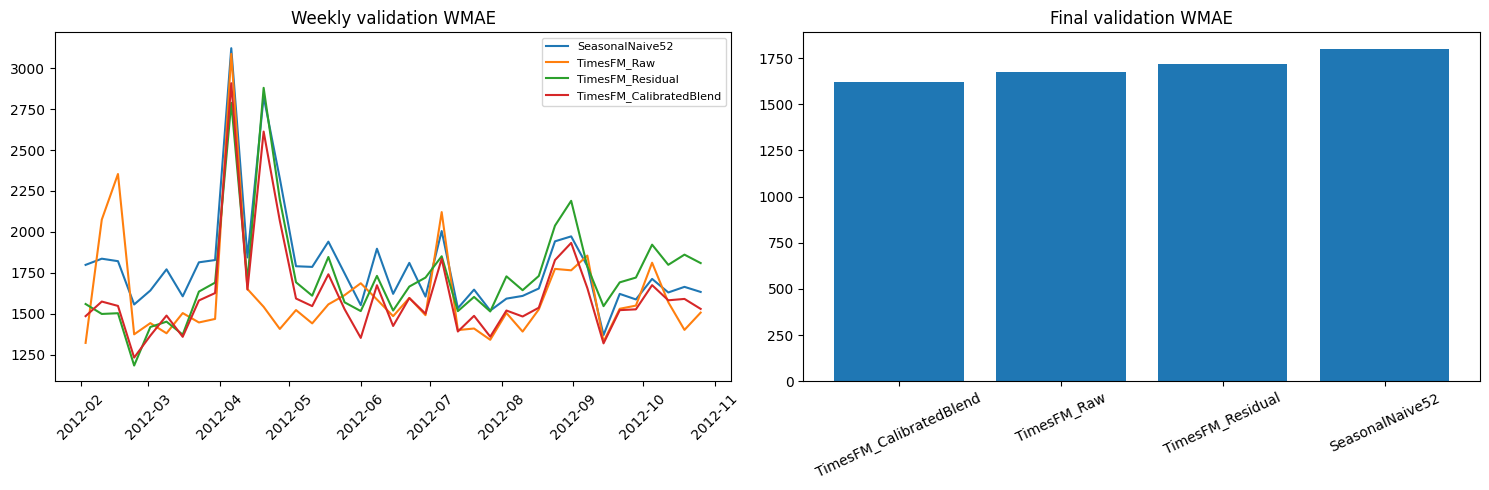

In [12]:
weekly=validation_df.groupby('Date').apply(lambda g:pd.Series({name:wmae(g.Weekly_Sales,g[name],g.IsHoliday,CONFIG['holiday_weight']) for name in candidate_columns}),include_groups=False).reset_index()
fig,axes=plt.subplots(1,2,figsize=(15,5))
for name in candidate_columns: axes[0].plot(weekly.Date,weekly[name],label=name)
axes[0].set_title('Weekly validation WMAE'); axes[0].tick_params(axis='x',rotation=45); axes[0].legend(fontsize=8)
axes[1].bar(score_table.candidate,score_table.validation_wmae); axes[1].set_title('Final validation WMAE'); axes[1].tick_params(axis='x',rotation=25)
plt.tight_layout(); plot_path=OUTPUT_DIR/'timesfm_v2_diagnostics.png'; fig.savefig(plot_path,dpi=160,bbox_inches='tight'); plt.show()

## w&b logging and reproducible evaluation artifact

In [13]:
paths={
 'calibration_predictions':OUTPUT_DIR/'calibration_predictions.csv','validation_predictions':OUTPUT_DIR/'validation_predictions.csv',
 'weight_search':OUTPUT_DIR/'weight_search.csv','scores':OUTPUT_DIR/'candidate_scores.csv','metrics':OUTPUT_DIR/'metrics.json'}
calibration_df.to_csv(paths['calibration_predictions'],index=False); validation_df.to_csv(paths['validation_predictions'],index=False)
weight_search.to_csv(paths['weight_search'],index=False); score_table.to_csv(paths['scores'],index=False)
manifest={'experiment':'TimesFM v2 zero-shot residual and calibrated blend','model_id':CONFIG['model_id'],'fine_tuned':False,'calibration_start':str(calibration_dates.min().date()),'calibration_end':str(calibration_dates.max().date()),'validation_start':str(validation_dates.min().date()),'validation_end':str(validation_dates.max().date()),'prediction_sha256':prediction_hash,**metrics}
paths['metrics'].write_text(json.dumps(manifest,indent=2))
run=wandb.init(entity=CONFIG['wandb_entity'],project=CONFIG['wandb_project'],group='timesfm-experiments',job_type='zero_shot_residual_calibration',name=CONFIG['wandb_run_name'],config=CONFIG)
run.log(metrics); run.log({'results/candidate_scores':wandb.Table(dataframe=score_table),'calibration/top_weights':wandb.Table(dataframe=weight_search.head(50)),'validation/predictions':wandb.Table(dataframe=validation_df.head(20000)),'validation/diagnostics':wandb.Image(str(plot_path))})
artifact=wandb.Artifact('timesfm-v2-zero-shot-residual-calibration',type='evaluation',metadata=manifest)
for path in [*paths.values(),plot_path]: artifact.add_file(str(path))
run.log_artifact(artifact,aliases=['v2','latest']); run.summary.update(manifest); run.finish()
print({'wandb_logged':True,'artifact':artifact.name,'output_dir':str(OUTPUT_DIR)})

calibration/best_w_naive,▁
calibration/best_w_raw,▁
calibration/best_w_residual,▁
calibration/best_wmae,▁
coverage/series,▁
runtime/inference_minutes,▁
runtime/model_load_seconds,▁
runtime/peak_gpu_gb,▁
validation/improvement_vs_raw_timesfm_pct,▁
validation/raw_timesfm_wmae,▁
+3,...


{'wandb_logged': True, 'artifact': 'timesfm-v2-zero-shot-residual-calibration', 'output_dir': '/content/artifacts/timesfm_zero_shot_v2'}


## result interpretation

the primary metric is `validation/wmae`, produced by weights selected only on the earlier calibration period. compare it with `validation/raw_timesfm_wmae` and `validation/residual_timesfm_wmae`. this remains a zero-shot experiment: no timesfm parameter was updated and no model registry pipeline is created yet.